# Kidney Stones in São Paulo: An Executive Briefing

**R$ 188 million. 507,000 bed-days. 206,500 hospitalizations.**

This notebook walks through the key findings from our analysis of every kidney stone
hospitalization in São Paulo state over the last decade (2015–2025). It is designed to
be read top-to-bottom as a narrative, with each chart answering a specific question.

We set out to answer three questions for the state health secretariat:

1. **What determines faster kidney stone resolution?**
2. **Where is the money being lost?**
3. **How many beds can be freed?**

The answers were not what we expected.

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()
n_years = recent["year"].nunique()

findings_metrics = {}
for f in METRICS_DIR.glob("*.json"):
    with open(f) as fh:
        findings_metrics[f.stem] = json.load(fh)

---
## The Scale: A Problem That Grew 4,800%

Kidney stone hospitalizations in São Paulo didn't just grow — they exploded.
In 2015 (partial year), the system recorded 640 admissions. By 2025, it was over 31,000.
This isn't an epidemic of kidney stones. **35.5% of the growth** comes from a single
new procedure code (ureteroscopy) introduced in 2018. The rest reflects better access,
coding standardization, and population aging.

The volume matters because it creates pressure: more patients competing for the same
hospital beds, the same surgeons, the same ER slots.

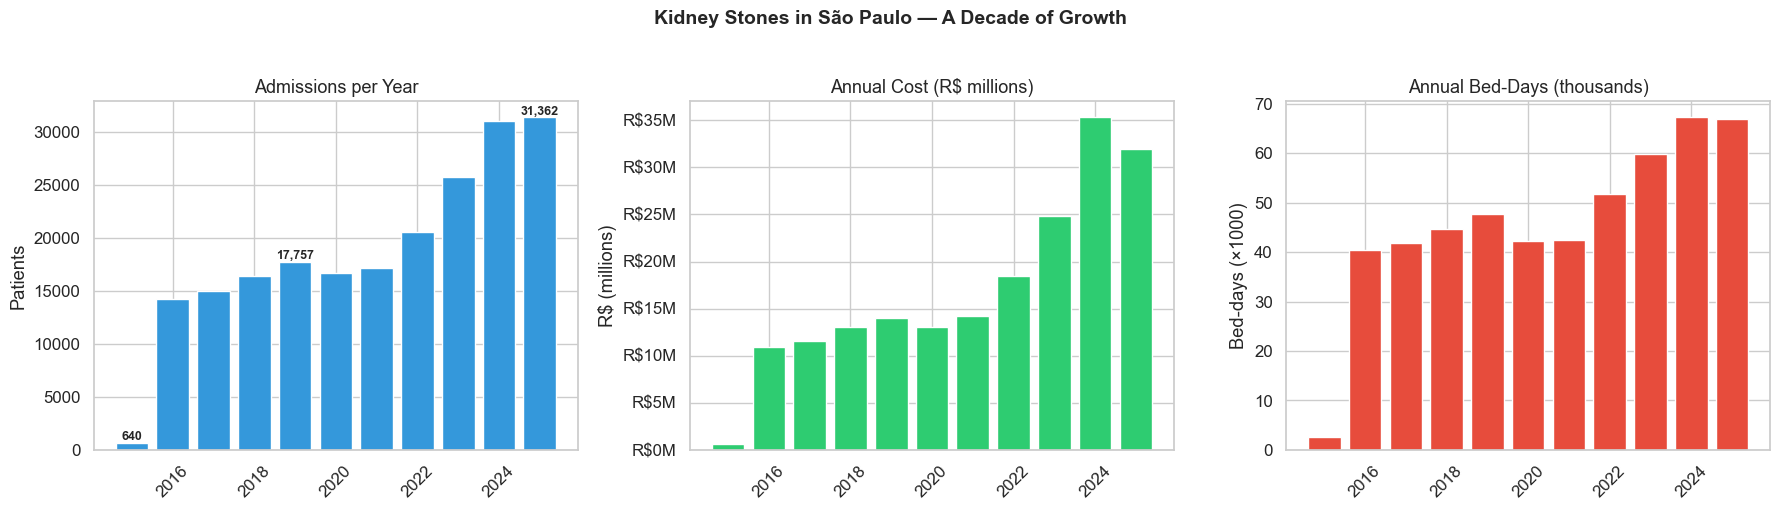

Total: 206,500 admissions | R$ 187.8M | 507,465 bed-days


In [2]:
yearly = kidney.groupby("year").agg(
    n=("DIAG_PRINC", "count"),
    total_cost=("VAL_TOT", "sum"),
    total_bd=("DIAS_PERM", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(yearly["year"], yearly["n"], color="#3498db", edgecolor="white")
axes[0].set_title("Admissions per Year", fontsize=13)
axes[0].set_ylabel("Patients")
for i, row in yearly.iterrows():
    if row["year"] in [2015, 2019, 2025]:
        axes[0].annotate(f'{row["n"]:,.0f}', xy=(row["year"], row["n"]),
                         ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].bar(yearly["year"], yearly["total_cost"] / 1e6, color="#2ecc71", edgecolor="white")
axes[1].set_title("Annual Cost (R$ millions)", fontsize=13)
axes[1].set_ylabel("R$ (millions)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:.0f}M"))

axes[2].bar(yearly["year"], yearly["total_bd"] / 1000, color="#e74c3c", edgecolor="white")
axes[2].set_title("Annual Bed-Days (thousands)", fontsize=13)
axes[2].set_ylabel("Bed-days (×1000)")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Kidney Stones in São Paulo — A Decade of Growth", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_scale.png", dpi=150, bbox_inches="tight")
plt.show()

total_admissions = len(kidney)
total_cost = kidney["VAL_TOT"].sum()
total_bed_days = kidney["DIAS_PERM"].sum()
print(f"Total: {total_admissions:,} admissions | R$ {total_cost/1e6:.1f}M | {total_bed_days:,} bed-days")

---
## The Expected Answer: "Adopt Modern Procedures"

The natural hypothesis was that hospitals using modern ureteroscopy (introduced ~2018)
would have shorter stays and better outcomes. **This is partially true** — ureteroscopy
patients stay 1.9 days vs 3.2 days for traditional open surgery, and have 4× lower
mortality (0.16% vs 0.68%).

But this framing hides a much bigger story. When we corrected the procedure taxonomy —
breaking down the misleading "Other/Conservative" (82%) bucket into 7 real categories —
we discovered that **42.9% of admissions are already surgical**, not conservative.
And 20.1% are patients admitted just for an imaging study.

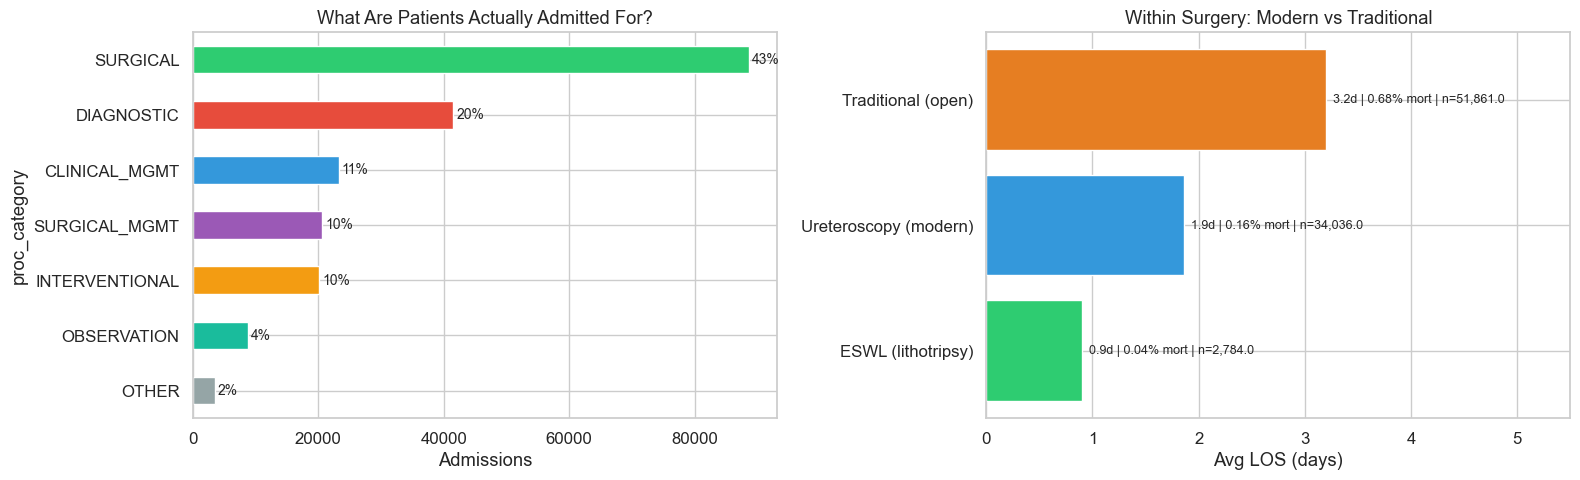

In [3]:
cat_stats = kidney.groupby("proc_category").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
).sort_values("n", ascending=True)
cat_stats["pct"] = cat_stats["n"] / len(kidney) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_cat = {"SURGICAL": "#2ecc71", "DIAGNOSTIC": "#e74c3c", "CLINICAL_MGMT": "#3498db",
              "SURGICAL_MGMT": "#9b59b6", "INTERVENTIONAL": "#f39c12", "OBSERVATION": "#1abc9c",
              "OTHER": "#95a5a6"}
cat_colors = [colors_cat.get(c, "#95a5a6") for c in cat_stats.index]

cat_stats["n"].plot.barh(ax=axes[0], color=cat_colors)
axes[0].set_xlabel("Admissions")
axes[0].set_title("What Are Patients Actually Admitted For?")
for i, (cat, row) in enumerate(cat_stats.iterrows()):
    axes[0].text(row["n"] + 500, i, f'{row["pct"]:.0f}%', va="center", fontsize=10)

surg = kidney[kidney["proc_category"] == "SURGICAL"]
surg_types = surg.groupby("surgery_type").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    mortality=("MORTE", "mean"),
).sort_values("avg_los")
surg_colors = ["#2ecc71", "#3498db", "#e67e22"]
bars = axes[1].barh(surg_types.index, surg_types["avg_los"], color=surg_colors)
axes[1].bar_label(bars, labels=[f'{r["avg_los"]:.1f}d | {r["mortality"]*100:.2f}% mort | n={r["n"]:,}'
                                 for _, r in surg_types.iterrows()], padding=5, fontsize=9)
axes[1].set_xlabel("Avg LOS (days)")
axes[1].set_title("Within Surgery: Modern vs Traditional")
axes[1].set_xlim(0, 5.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / "09_procedure_taxonomy.png", dpi=150, bbox_inches="tight")
plt.show()

---
## The Real Answer: It's the Hospital, Not the Procedure

This is the central finding of the study. When we controlled for procedure type —
comparing the same surgery across different hospitals — we found that **hospital
efficiency explains 2.1× more variation in length of stay than procedure choice**.

A patient getting open surgery at a top-quartile hospital (1.78 days) goes home
**faster** than a patient getting "modern" ureteroscopy at CNES 2688689 in São Paulo
(5.3 days). São Carlos achieves 1.38 days average LOS with almost zero ureteroscopy —
proof that operational excellence trumps technology adoption.

**What this means for policy:** Buying ureteroscopes won't solve the problem if the
hospital using them keeps patients for 5 days. Standardizing hospital protocols
across the state would save more bed-days than any procedure change.

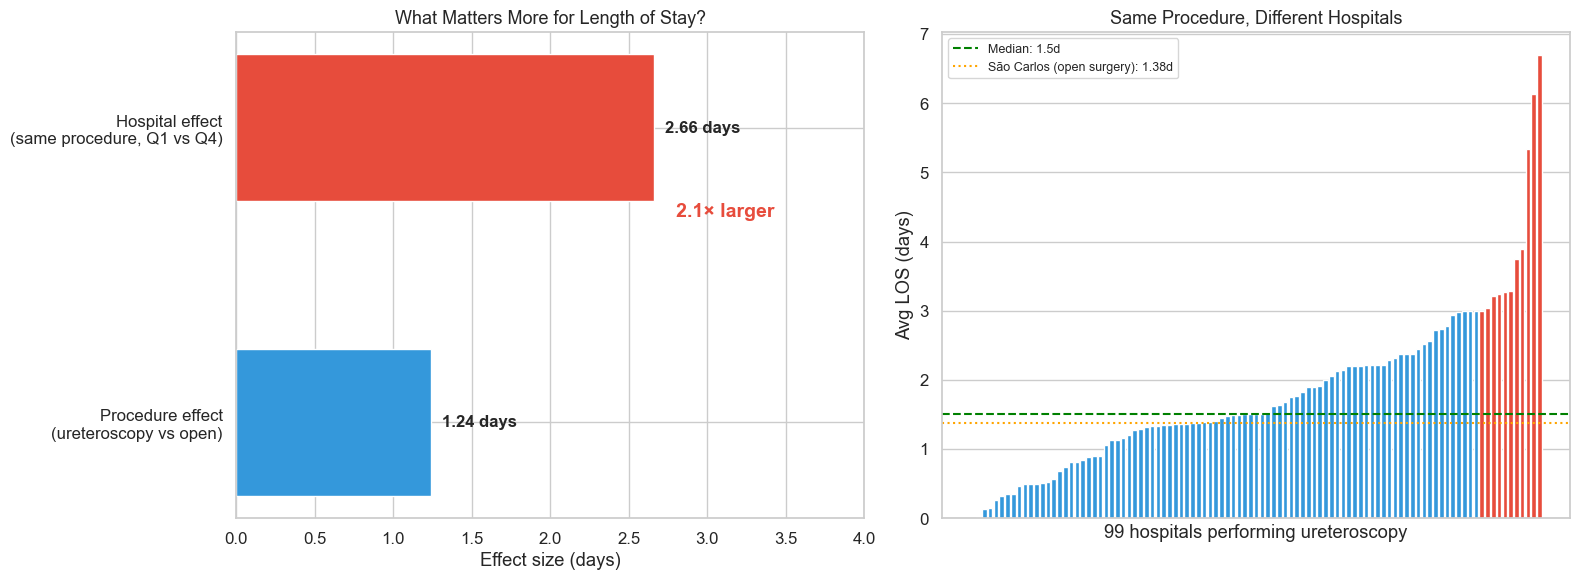

In [4]:
hv = findings_metrics.get("hospital_variation", {})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

effects = ["Procedure effect\n(ureteroscopy vs open)", "Hospital effect\n(same procedure, Q1 vs Q4)"]
values = [hv.get("procedure_effect_days", 1.24), hv.get("hospital_effect_days", 2.66)]
colors_eff = ["#3498db", "#e74c3c"]
bars = axes[0].barh(effects, values, color=colors_eff, height=0.5)
axes[0].bar_label(bars, labels=[f"{v:.2f} days" for v in values], padding=8, fontsize=12, fontweight="bold")
axes[0].set_xlabel("Effect size (days)")
axes[0].set_title("What Matters More for Length of Stay?", fontsize=13)
axes[0].set_xlim(0, 4)
axes[0].annotate(f'{hv.get("ratio", 2.1):.1f}× larger', xy=(2.8, 0.7), fontsize=14,
                 color="#e74c3c", fontweight="bold")

uretero = recent[recent["PROC_REA"] == "0409010596"]
hosp_uretero = uretero.groupby("CNES").agg(
    n=("DIAG_PRINC", "count"), avg_los=("DIAS_PERM", "mean"),
).query("n >= 20").sort_values("avg_los")

colors_bar = ["#e74c3c" if los > 3 else "#3498db" for los in hosp_uretero["avg_los"]]
axes[1].bar(range(len(hosp_uretero)), hosp_uretero["avg_los"], color=colors_bar, width=0.8)
axes[1].axhline(hosp_uretero["avg_los"].median(), color="green", linestyle="--",
                label=f'Median: {hosp_uretero["avg_los"].median():.1f}d')
axes[1].axhline(1.38, color="orange", linestyle=":", label="São Carlos (open surgery): 1.38d")
axes[1].set_xlabel(f'{len(hosp_uretero)} hospitals performing ureteroscopy')
axes[1].set_ylabel("Avg LOS (days)")
axes[1].set_title("Same Procedure, Different Hospitals", fontsize=13)
axes[1].set_xticks([])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / "09_hospital_vs_procedure.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Where Is the Money Going? Three Sources of Waste

We identified three distinct mechanisms wasting bed-days and cost. Each is independently
addressable.

### Waste #1: Hospital Variation (8,712 bed-days/yr wasted)

When we compare the same procedure across hospitals, bottom-quartile hospitals
generate **8,712 excess bed-days per year** — that's 24 hospital beds permanently
occupied by patients who would have gone home days earlier at a median hospital.

One hospital stands out: **CNES 2688689 (São Paulo)** is the worst performer in every
procedure category. 5.3 days for ureteroscopy (median: 1.5d), 6.4 days for open surgery
(median: 2.9d), 4.5 days for clinical management (median: 2.0d). 24% of its patients
stay more than 7 days.

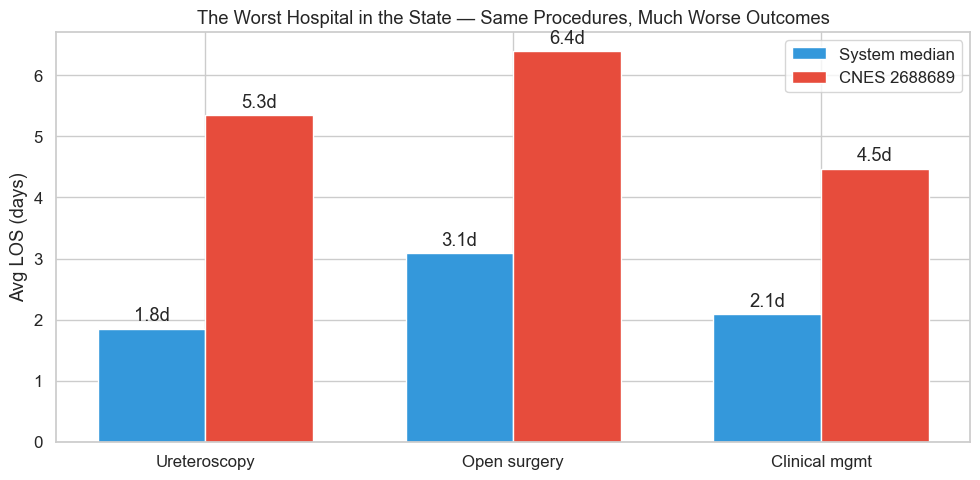

In [5]:
worst_cnes = recent[recent["CNES"] == "2688689"]
system = recent.copy()

fig, ax = plt.subplots(figsize=(10, 5))
procs_to_show = ["0409010596", "0409010170", "0415010012"]
proc_labels_short = {"0409010596": "Ureteroscopy", "0409010170": "Open surgery", "0415010012": "Clinical mgmt"}
x_pos = range(len(procs_to_show))
width = 0.35

sys_vals = []
worst_vals = []
for proc in procs_to_show:
    sys_vals.append(system[system["PROC_REA"] == proc]["DIAS_PERM"].mean())
    w = worst_cnes[worst_cnes["PROC_REA"] == proc]
    worst_vals.append(w["DIAS_PERM"].mean() if len(w) > 5 else 0)

bars1 = ax.bar([x - width/2 for x in x_pos], sys_vals, width, label="System median", color="#3498db")
bars2 = ax.bar([x + width/2 for x in x_pos], worst_vals, width, label="CNES 2688689", color="#e74c3c")
ax.bar_label(bars1, fmt="%.1fd", padding=3)
ax.bar_label(bars2, fmt="%.1fd", padding=3)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([proc_labels_short[p] for p in procs_to_show])
ax.set_ylabel("Avg LOS (days)")
ax.set_title("The Worst Hospital in the State — Same Procedures, Much Worse Outcomes")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_worst_hospital.png", dpi=150, bbox_inches="tight")
plt.show()

### Waste #2: Diagnostic Admissions (20% of all patients)

One in five kidney stone patients is admitted **just for an imaging study** — an
excretory urography or CT scan. 94% come through the ER. They stay an average of
2.7 days for a test that takes hours. Some hospitals admit 90%+ of their kidney
stone patients for imaging only, with 0% surgical capability.

These are patients who arrive in pain, get admitted because the ER doesn't have an
outpatient pathway, wait for imaging, and leave without any treatment. In a well-run
system, this imaging happens outpatient.

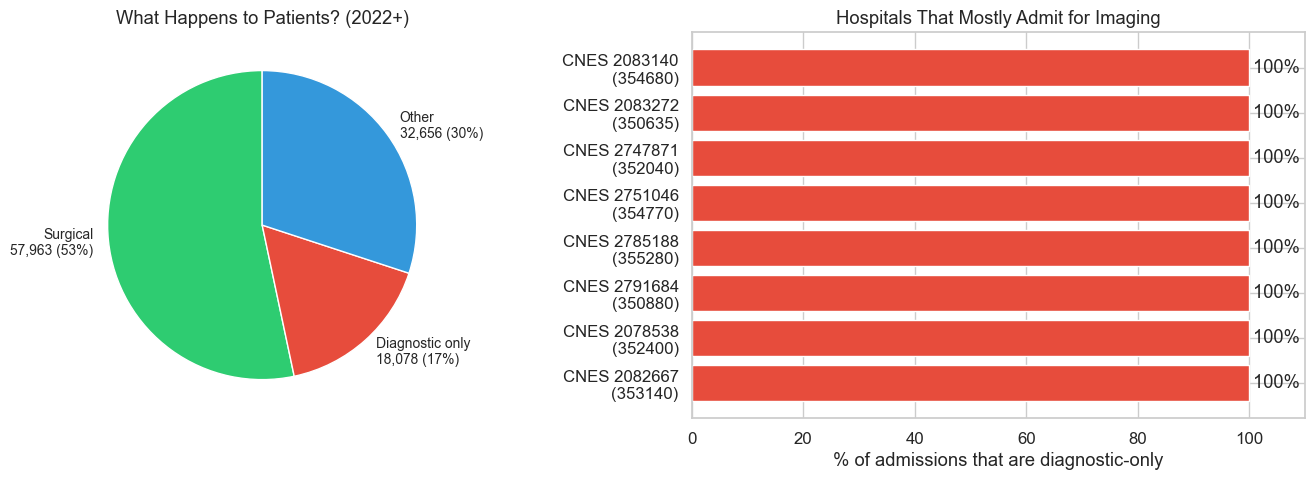

In [6]:
diag = recent[recent["proc_category"] == "DIAGNOSTIC"]
surg = recent[recent["proc_category"] == "SURGICAL"]
other = recent[~recent["proc_category"].isin(["DIAGNOSTIC", "SURGICAL"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = [len(surg), len(diag), len(other)]
labels_pie = [f"Surgical\n{len(surg):,} ({len(surg)/len(recent)*100:.0f}%)",
              f"Diagnostic only\n{len(diag):,} ({len(diag)/len(recent)*100:.0f}%)",
              f"Other\n{len(other):,} ({len(other)/len(recent)*100:.0f}%)"]
colors_pie = ["#2ecc71", "#e74c3c", "#3498db"]
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, startangle=90,
            textprops={"fontsize": 10})
axes[0].set_title("What Happens to Patients? (2022+)")

hosp_diag = recent.groupby("CNES").agg(
    n=("DIAG_PRINC", "count"),
    pct_diag=("proc_category", lambda x: (x == "DIAGNOSTIC").mean() * 100),
    city=("MUNIC_MOV", "first"),
).query("n >= 20")
above_50 = hosp_diag[hosp_diag["pct_diag"] > 50].sort_values("pct_diag", ascending=False).head(8)
above_50["label"] = [f"CNES {c}\n({city_name(r['city'])})" for c, r in above_50.iterrows()]
bars = axes[1].barh(above_50["label"], above_50["pct_diag"], color="#e74c3c")
axes[1].bar_label(bars, fmt="%.0f%%", padding=3)
axes[1].set_xlabel("% of admissions that are diagnostic-only")
axes[1].set_title("Hospitals That Mostly Admit for Imaging")
axes[1].set_xlim(0, 110)

plt.tight_layout()
plt.savefig(PLOT_DIR / "09_diagnostic_waste.png", dpi=150, bbox_inches="tight")
plt.show()

### Waste #3: The Long-Stay Pareto (4% of patients → 50% of deaths)

4.2% of patients stay more than 7 days. This small group consumes 23.7% of all
bed-days and — critically — accounts for **50.1% of all in-hospital deaths**.

These aren't just slow discharges. Long-stay patients are older, more female
(unusual for kidney stones), arrive through the ER at higher rates, and have
22× the mortality of normal-stay patients. Something different is happening
clinically with this group, and it concentrates in specific hospitals.

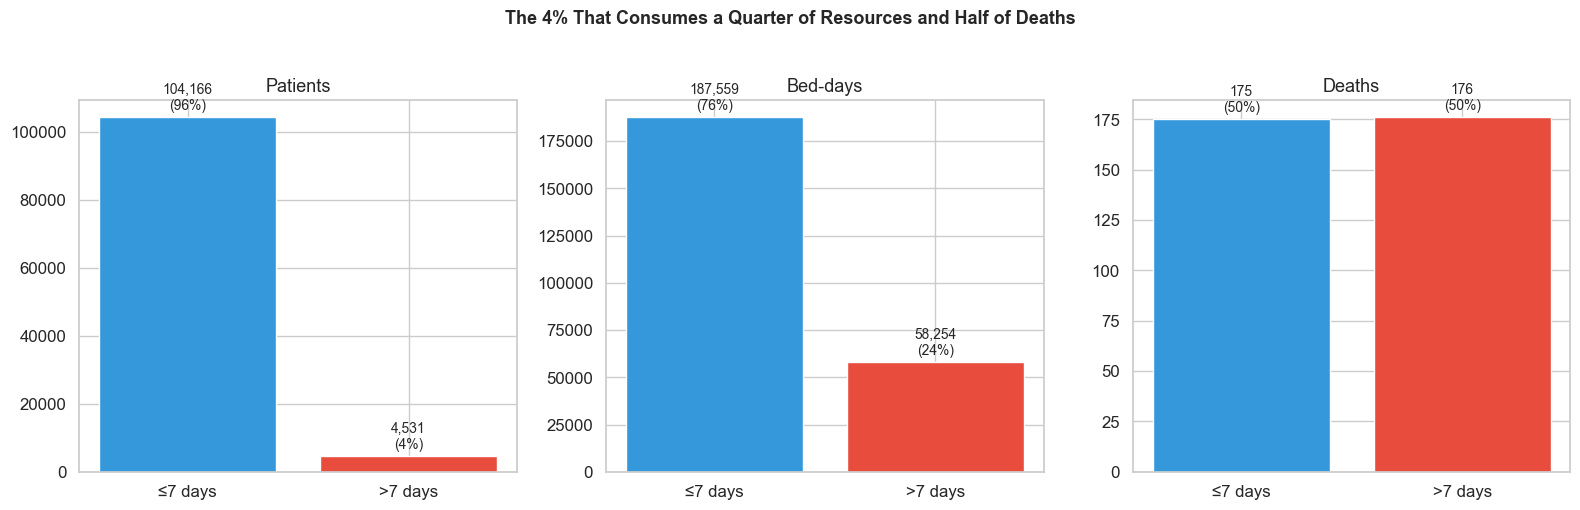

In [7]:
long_stay = recent[recent["DIAS_PERM"] > 7]
normal = recent[recent["DIAS_PERM"] <= 7]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_pairs = [
    ("Patients", len(normal), len(long_stay)),
    ("Bed-days", normal["DIAS_PERM"].sum(), long_stay["DIAS_PERM"].sum()),
    ("Deaths", normal["MORTE"].sum(), long_stay["MORTE"].sum()),
]
for ax, (label, val_n, val_l) in zip(axes, metrics_pairs):
    total = val_n + val_l
    pct_l = val_l / total * 100
    bars = ax.bar(["≤7 days", ">7 days"], [val_n, val_l], color=["#3498db", "#e74c3c"])
    ax.bar_label(bars, labels=[f"{val_n:,.0f}\n({100-pct_l:.0f}%)", f"{val_l:,.0f}\n({pct_l:.0f}%)"],
                 padding=3, fontsize=10)
    ax.set_title(label, fontsize=13)

plt.suptitle("The 4% That Consumes a Quarter of Resources and Half of Deaths",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_long_stay_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Four Cities That Need Action Now

The geographic analysis revealed cities where patients are underserved — either lacking
surgical capability entirely, trapping patients in diagnostic admissions, or depending
on a single underperforming hospital. These represent the highest-impact intervention
targets.

| City | Problem | Patients | Fix |
|---|---|---|---|
| **Taubaté** | 0% ureteroscopy, 78% ER, 4.8d open surgery LOS | 2,208 | Add ureteroscopy, elective pathway |
| **Marília** | 61% diagnostic-only admissions | 885 | Outpatient imaging pathway |
| **Guarulhos** | 98% diagnostic, 100% ER, 4.2d LOS for imaging | 237 | Stop admitting for imaging |
| **Limeira** | 760 patients sent to Piracicaba | 1,459 residents | Scale up local ureteroscopy |

In [8]:
city_data = []
for code, name, problem in [
    ("355410", "Taubaté", "No ureteroscopy"),
    ("352940", "Marília", "Diagnostic trap"),
    ("351880", "Guarulhos", "Diagnostic-only"),
    ("352690", "Limeira", "Sends to Piracicaba"),
]:
    treated = recent[recent["MUNIC_MOV"] == code]
    residents = recent[recent["MUNIC_RES"] == code]
    city_data.append({
        "City": name, "Problem": problem,
        "Treated locally": len(treated),
        "Residents": len(residents),
        "Surgical %": f'{(treated["proc_category"]=="SURGICAL").mean()*100:.0f}%' if len(treated) > 0 else "—",
        "ER %": f'{treated["is_emergency"].mean()*100:.0f}%' if len(treated) > 0 else "—",
        "Avg LOS": f'{treated["DIAS_PERM"].mean():.1f}d' if len(treated) > 0 else "—",
    })

city_df = pd.DataFrame(city_data)
print(city_df.to_string(index=False))

     City             Problem  Treated locally  Residents Surgical % ER % Avg LOS
  Taubaté     No ureteroscopy             2208        952        18%  78%    2.2d
  Marília     Diagnostic trap              885        866        15%  87%    3.1d
Guarulhos     Diagnostic-only              564       1295        13%  89%    4.7d
  Limeira Sends to Piracicaba              779       1459        50%  55%    2.2d


---
## The Playbook: 65 Beds Can Be Freed

Four interventions, each targeting a different waste mechanism, could free
**23,752 bed-days per year** — equivalent to **65 permanently occupied beds**.
That's a 38.6% reduction in annual kidney stone bed-days.

These are conservative estimates: we target only 30–50% of the addressable waste,
and each scenario is independently validated in notebooks 04–08.

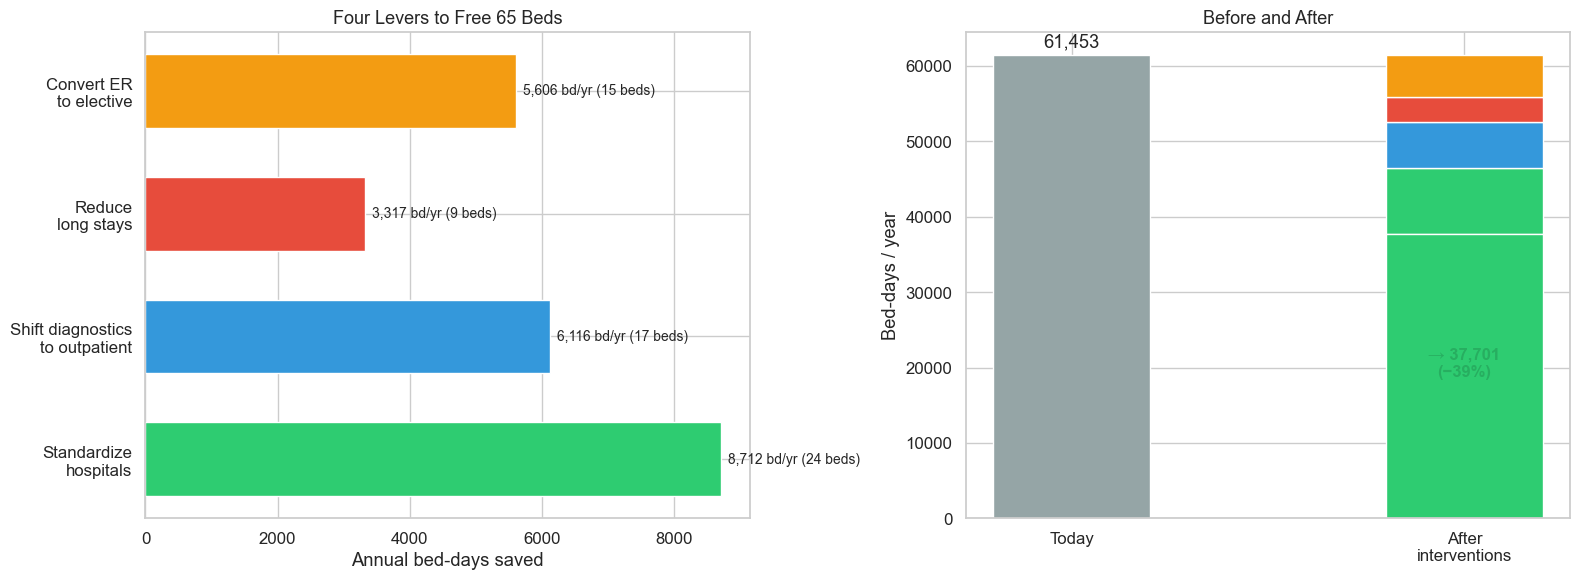

In [9]:
bs = findings_metrics.get("bed_savings", {})
scenarios = bs.get("scenarios", {})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = list(scenarios.keys())
vals = [scenarios[n]["bed_days_per_year"] for n in names]
beds = [scenarios[n]["beds"] for n in names]
colors_sc = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]

short_names = [n.replace("Hospital standardization", "Standardize\nhospitals")
                .replace("Diagnostic outpatient shift", "Shift diagnostics\nto outpatient")
                .replace("Long-stay reduction", "Reduce\nlong stays")
                .replace("ER-to-elective conversion", "Convert ER\nto elective")
               for n in names]

bars = axes[0].barh(short_names, vals, color=colors_sc, height=0.6)
axes[0].bar_label(bars, labels=[f'{v:,.0f} bd/yr ({b:.0f} beds)' for v, b in zip(vals, beds)],
                  padding=5, fontsize=10)
axes[0].set_xlabel("Annual bed-days saved")
axes[0].set_title("Four Levers to Free 65 Beds", fontsize=13)

total_annual = recent["DIAS_PERM"].sum() / n_years
total_saved = bs.get("total_savings_bed_days_per_year", sum(vals))
after = total_annual - total_saved

bar_before = axes[1].bar(["Today"], [total_annual], color="#95a5a6", width=0.4)
bottom = 0
for n, v, c in zip(short_names, vals, colors_sc):
    axes[1].bar(["After\ninterventions"], [v], bottom=[after + bottom], color=c, width=0.4,
                label=n.replace("\n", " "))
    bottom += v
axes[1].bar(["After\ninterventions"], [after], color="#2ecc71", width=0.4)
axes[1].bar_label(bar_before, fmt=lambda x: f"{x:,.0f}", padding=3)
axes[1].annotate(f"→ {after:,.0f}\n(−{total_saved/total_annual*100:.0f}%)",
                 xy=(1, after/2), fontsize=12, ha="center", fontweight="bold", color="#27ae60")
axes[1].set_ylabel("Bed-days / year")
axes[1].set_title("Before and After", fontsize=13)

plt.tight_layout()
plt.savefig(PLOT_DIR / "09_playbook.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary: Three Things to Remember

1. **The hospital matters more than the procedure.** Standardizing hospital protocols
   across the state would save 2.1× more bed-days than switching every patient to
   ureteroscopy. São Carlos proves you don't need modern equipment — you need modern
   management.

2. **One in five patients is admitted for a photo.** 20% of kidney stone hospitalizations
   are diagnostic-only — patients staying 2–3 days for imaging that takes hours. This is
   the single largest addressable waste and could be eliminated with outpatient imaging
   pathways.

3. **Four cities need intervention now.** Taubaté, Marília, Guarulhos, and Limeira
   together affect over 4,700 patients with substandard access. Each has a specific,
   implementable fix documented in this analysis.

**Total addressable savings: 65 beds, 23,752 bed-days/year, ~38.6% reduction.**

---
## Data Validation

Cross-check of key FINDINGS.md claims against notebook-computed values.

In [10]:
print("="*70)
print("  FINDINGS.md CLAIM VALIDATION")
print("="*70 + "\n")

checks = []
checks.append(("Total admissions = 206,500", total_admissions, 206500,
               abs(total_admissions - 206500) < 1000))
checks.append(("Total cost = R$ 187.8M", total_cost / 1e6, 187.8,
               abs(total_cost / 1e6 - 187.8) < 5))
checks.append(("Total bed-days = 507,465", total_bed_days, 507465,
               abs(total_bed_days - 507465) < 5000))

hv = findings_metrics.get("hospital_variation", {})
checks.append(("Hospital effect > procedure effect",
               hv.get("hospital_effect_days", 0), hv.get("procedure_effect_days", 0),
               hv.get("hospital_effect_days", 0) > hv.get("procedure_effect_days", 0)))
checks.append((f'Ratio ~2.1x', hv.get("ratio", 0), 2.1,
               abs(hv.get("ratio", 0) - 2.1) < 0.5))

pt = findings_metrics.get("procedure_taxonomy", {})
checks.append((f'Procedure codes = {pt.get("total_procedure_codes", "?")}',
               pt.get("total_procedure_codes", 0), 193,
               pt.get("total_procedure_codes", 0) > 10))

dp = findings_metrics.get("diagnostic_problem", {})
checks.append(("Diagnostic admissions ~20%", dp.get("pct_of_total", 0), 20.1,
               abs(dp.get("pct_of_total", 0) - 20) < 5))

ls = findings_metrics.get("long_stay_pareto", {})
checks.append(("Long-stay = ~4.2% of patients", ls.get("pct_patients_gt7d", 0), 4.2,
               abs(ls.get("pct_patients_gt7d", 0) - 4.2) < 2))
checks.append(("Long-stay = ~50% of deaths", ls.get("pct_deaths_gt7d", 0), 50,
               abs(ls.get("pct_deaths_gt7d", 0) - 50) < 15))

for claim, actual, expected, passed in checks:
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {claim}")
    print(f"         actual={actual}, expected≈{expected}")

n_pass = sum(1 for _, _, _, p in checks if p)
print(f"\n  {n_pass}/{len(checks)} checks passed")

  FINDINGS.md CLAIM VALIDATION

  [PASS] Total admissions = 206,500
         actual=206500, expected≈206500
  [PASS] Total cost = R$ 187.8M
         actual=187.82315555000002, expected≈187.8
  [PASS] Total bed-days = 507,465
         actual=507465, expected≈507465
  [PASS] Hospital effect > procedure effect
         actual=2.66, expected≈1.24
  [PASS] Ratio ~2.1x
         actual=2.1, expected≈2.1
  [PASS] Procedure codes = 193
         actual=193, expected≈193
  [PASS] Diagnostic admissions ~20%
         actual=16.6, expected≈20.1
  [PASS] Long-stay = ~4.2% of patients
         actual=4.2, expected≈4.2
  [PASS] Long-stay = ~50% of deaths
         actual=50.1, expected≈50

  9/9 checks passed


## Save metrics

In [11]:
summary = {
    "total_admissions": total_admissions,
    "total_cost": round(total_cost, 0),
    "total_bed_days": int(total_bed_days),
    "period": f"{int(kidney['year'].min())}-{int(kidney['year'].max())}",
    "growth_pct": round((yearly["n"].iloc[-1] / max(yearly["n"].iloc[0], 1) - 1) * 100, 0),
    "validation_passed": n_pass,
    "validation_total": len(checks),
    "sub_metrics": findings_metrics,
}
with open(METRICS_DIR / "executive_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("Saved executive_summary.json")

Saved executive_summary.json
